<a href="https://colab.research.google.com/github/UKD1211/100_days_ML_cX_ISI_DS/blob/main/bagging_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
himanshunakrani_iris_dataset_path = kagglehub.dataset_download('himanshunakrani/iris-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv


In [ ]:
df = pd.read_csv("/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv")

In [ ]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

In [ ]:
df['species'] = encoder.fit_transform(df['species'])

In [ ]:
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,2
135,7.7,3.0,6.1,2.3,2
59,5.2,2.7,3.9,1.4,1
7,5.0,3.4,1.5,0.2,0
34,4.9,3.1,1.5,0.1,0
41,4.5,2.3,1.3,0.3,0
105,7.6,3.0,6.6,2.1,2
40,5.0,3.5,1.3,0.3,0
13,4.3,3.0,1.1,0.1,0
80,5.5,2.4,3.8,1.1,1


In [ ]:
df = df[['sepal_width','petal_length','species']]

In [ ]:
df = df[df['species'] != 0]

In [ ]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


<Axes: xlabel='sepal_width', ylabel='petal_length'>

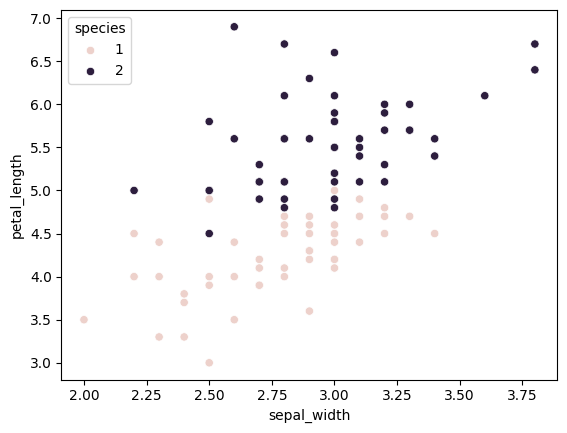

In [ ]:
import seaborn as sns
sns.scatterplot(data =df,x = 'sepal_width',y = 'petal_length',hue = 'species', color = 'winter')

In [ ]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [ ]:
df

,sepal_width,petal_length,species
81,2.4,3.7,1
59,2.7,3.9,1
127,3.0,4.9,2
83,2.7,5.1,1
68,2.2,4.5,1
...,...,...,...
135,3.0,6.1,2
136,3.4,5.6,2
143,3.2,5.9,2
122,2.8,6.7,2


In [ ]:
df_train

,sepal_width,petal_length,species
54,2.8,4.6,1
117,3.8,6.7,2
141,3.1,5.1,2
105,3.0,6.6,2
61,3.0,4.2,1
113,2.5,5.0,2
57,2.4,3.3,1
86,3.1,4.7,1
100,3.3,6.0,2
83,2.7,5.1,1


In [ ]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [ ]:
X_test

array([[3.2, 6. ],
       [2.8, 5.1],
       [3.1, 5.4],
       [3. , 5.5],
       [2.5, 4.5]])

**Bagging**

In [ ]:
# Data for tree1

df_bag = df_train.sample(8,replace = True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
57,2.4,3.3,1
117,3.8,6.7,2
100,3.3,6.0,2
61,3.0,4.2,1
113,2.5,5.0,2
83,2.7,5.1,1
100,3.3,6.0,2
105,3.0,6.6,2


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

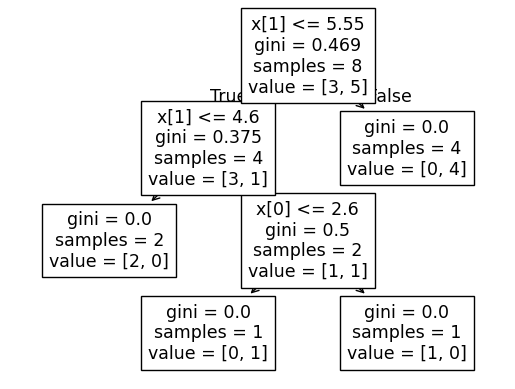

0.2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


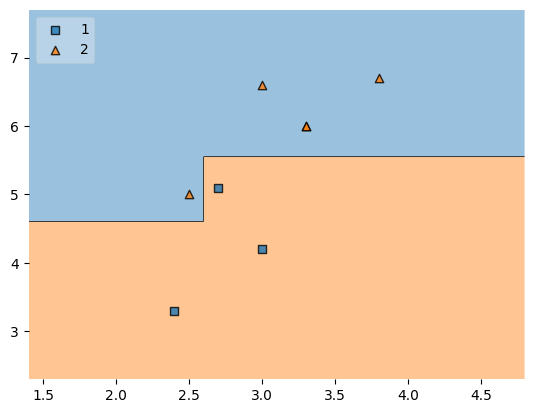

In [ ]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)

In [ ]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf = clf, legend = 2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))


In [ ]:
# Data for tree2

df_bag = df_train.sample(8,replace = True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
113,2.5,5.0,2
100,3.3,6.0,2
141,3.1,5.1,2
113,2.5,5.0,2
57,2.4,3.3,1
105,3.0,6.6,2
86,3.1,4.7,1
141,3.1,5.1,2


In [ ]:
dt_bag2 = DecisionTreeClassifier()

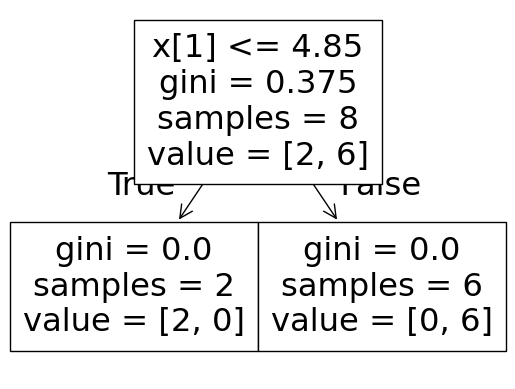

0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


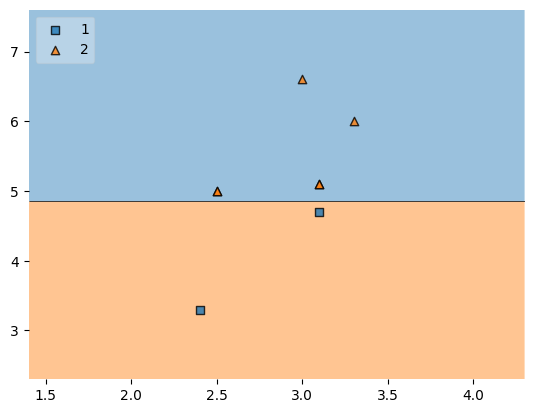

In [ ]:
evaluate(dt_bag2,X,y)

In [ ]:
# Data for tree3

df_bag = df_train.sample(8,replace = True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
57,2.4,3.3,1
100,3.3,6.0,2
117,3.8,6.7,2
83,2.7,5.1,1
57,2.4,3.3,1
86,3.1,4.7,1
54,2.8,4.6,1
83,2.7,5.1,1


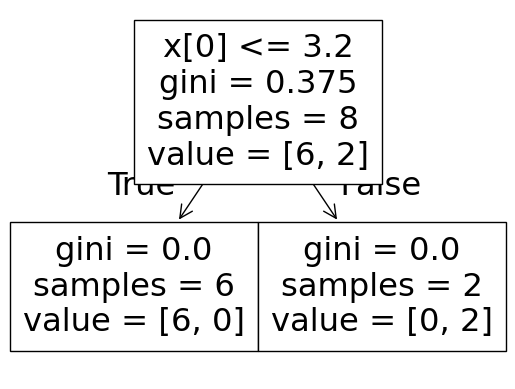

0.2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


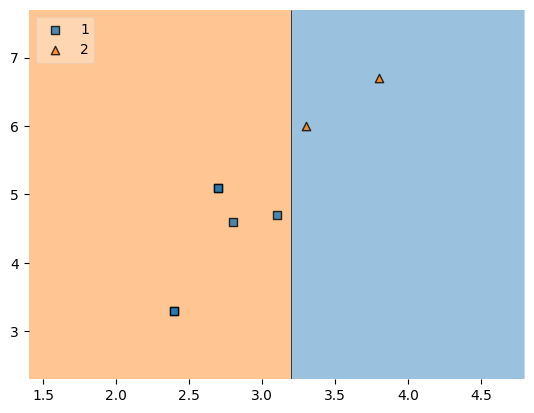

In [ ]:
 dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [ ]:
# predict

In [ ]:
df_test

,sepal_width,petal_length,species
120,3.2,5.7,2
69,2.5,3.9,1
126,2.8,4.8,2
143,3.2,5.9,2
140,3.1,5.6,2


In [ ]:
print("pred1",dt_bag1.predict(np.array([3.2,5.7]).reshape(1,2)))
print("pred2",dt_bag2.predict(np.array([3.2,5.7]).reshape(1,2)))
print("pred3",dt_bag3.predict(np.array([3.2,5.7]).reshape(1,2)))

pred1 [2]
pred2 [2]
pred3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Pasting

# Row sampling without replacement
df_train

,sepal_width,petal_length,species
54,2.8,4.6,1
117,3.8,6.7,2
141,3.1,5.1,2
105,3.0,6.6,2
61,3.0,4.2,1
113,2.5,5.0,2
57,2.4,3.3,1
86,3.1,4.7,1
100,3.3,6.0,2
83,2.7,5.1,1


In [ ]:
df_train.sample(8)

,sepal_width,petal_length,species
57,2.4,3.3,1
86,3.1,4.7,1
141,3.1,5.1,2
105,3.0,6.6,2
54,2.8,4.6,1
83,2.7,5.1,1
113,2.5,5.0,2
100,3.3,6.0,2


In [ ]:
#Random Subspaces
# df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df = df.sample(10)

In [ ]:
df

,sepal_width,petal_length,species
102,3.0,5.9,2
80,2.4,3.8,1
131,3.8,6.4,2
62,2.2,4.0,1
57,2.4,3.3,1
116,3.0,5.5,2
96,2.9,4.2,1
142,2.7,5.1,2
53,2.3,4.0,1
146,2.5,5.0,2


In [ ]:
df.sample(2,replace=True,axis=1)

,petal_length,sepal_width
102,5.9,3.0
80,3.8,2.4
131,6.4,3.8
62,4.0,2.2
57,3.3,2.4
116,5.5,3.0
96,4.2,2.9
142,5.1,2.7
53,4.0,2.3
146,5.0,2.5


In [ ]:
#Random patchs

In [ ]:
df

,sepal_width,petal_length,species
102,3.0,5.9,2
80,2.4,3.8,1
131,3.8,6.4,2
62,2.2,4.0,1
57,2.4,3.3,1
116,3.0,5.5,2
96,2.9,4.2,1
142,2.7,5.1,2
53,2.3,4.0,1
146,2.5,5.0,2


In [ ]:
df.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_width,petal_length
57,2.4,3.3
80,2.4,3.8
62,2.2,4.0
116,3.0,5.5
146,2.5,5.0
102,3.0,5.9
96,2.9,4.2
102,3.0,5.9
